In [1]:
import xarray as xr
import os
import glob
from tqdm import tqdm
import easyclimate as ec
import numpy as np
import matplotlib.pyplot as plt

def get_monthly_data(folder_path,regions,dim="time",ifCross180 = False):
    # Collect all NetCDF files in the folder
    file_list = sorted(glob.glob(os.path.join(folder_path, "*.nc")))

    # Initialize a dictionary to store the results for each region
    regional_data = {}

    # Process each region
    for region_name, bounds in tqdm(regions.items(),desc="Selected Regions"):
        min_lat, max_lat = bounds["lat"]
        min_lon, max_lon = bounds["lon"]
        
        # Initialize an empty list for the current region
        data_list = []

        for file in tqdm(file_list,desc="Read Files"):
            # Open the dataset
            ds = xr.open_dataset(file).rename({"time_counter": "time", "nav_lat": "lat", "nav_lon": "lon"})
            # Subset the region of interest
            if ifCross180:
                ds_subset = ds.where(
                (
                ((ds["lon"] >= max_lon) & (ds["lon"] <= 180)) |  # From 120°E to 180°
                ((ds["lon"] >= -180) & (ds["lon"] <= min_lon))  # From 180°W to 80°W
                ) &
                (ds["lat"] >= min_lat) & (ds["lat"] <= max_lat),  # Latitudes between -5° and 5°
                drop=True
                )
            else:
                ds_subset = ds.where((ds['lon'] >= min_lon) & (ds['lon'] <= max_lon) &
                            (ds['lat'] >= min_lat) & (ds['lat'] <= max_lat),)
            # Compute the spatial average over the region, ignoring NaNs
            ds_mean = ds_subset.mean(dim=("x", "y"), skipna=True)
            
            # Append the subsetted data to the list
            data_list.append(ds_mean)

        # Combine all the datasets along the 'time' dimension
        combined_data = xr.concat(data_list, dim=dim)
        
        # Store the combined dataset for the region
        regional_data[region_name] = combined_data

    return regional_data


In [2]:
# Path to the folder containing monthly files
folder_path = "SST/"
# Define the regions
regions = {
    "Nino34": {"lat": (-5, 5), "lon": (-170, -120)},
    "NPMM": {"lat": (10, 25), "lon": (-160, -120)},
    "SPMM": {"lat": (-25, -15), "lon": (-110, -90)},
    "IOB": {"lat": (-20, 20), "lon": (40, 100)},
    "IOD1": {"lat": (-10, 10), "lon": (50, 70)},
    "IOD2": {"lat": (-10, 0), "lon": (90, 110)},
    "SIOD1": {"lat": (-25, -10), "lon": (65, 85)},
    "SIOD2": {"lat": (-30, -5), "lon": (90, 120)},
    "TNA": {"lat": (5, 25), "lon": (-55, -15)},
    "ATL3": {"lat": (-3, 3), "lon": (-20, 0)},
    "SASD1" : {"lat": (-40, -30), "lon": (-30, -10)},
    "SASD2" : {"lat": (-25, -15), "lon": (-20, 0)},
}
sst_data = get_monthly_data(folder_path,regions)
# Now `regional_data` contains a combined dataset for each region
selected_dataset = xr.Dataset(
    {region_name: data["sosstsst"] for region_name, data in sst_data.items()}
)

# Path to the folder containing monthly files
folder_path = "WWV/"
# Define the regions
regions = {
    "WWV": {"lat": (-5, 5), "lon": (-80,120)},
}
wwv_data = get_monthly_data(folder_path,regions,ifCross180=True)
selected_dataset["WWV"] = wwv_data["WWV"]["so20chgt"]

Selected Regions: 100%|██████████| 1/1 [01:12<00:00, 72.97s/it]


In [3]:
# Fit a quadratic trend (2nd degree polynomial)
def fit_quadratic_trend(data, time):
    """
    Fits a quadratic trend to the data along a time dimension.
    Handles NaN and Inf values by filtering them out.
    """
    # Remove NaN or Inf values
    mask = np.isfinite(data)
    if np.sum(mask) < 3:  # Require at least 3 points for a quadratic fit
        return np.array([np.nan, np.nan, np.nan])  # Return NaNs if insufficient data
    else:
        return np.polyfit(time[mask], data[mask], deg=2)  # Quadratic fit

def detrend(ds, variable,dim, inplace=True):
    # Convert time to "months since the start of the dataset"
    time_numeric = (ds[dim].dt.year - ds[dim][0].dt.year) * 12 + (ds[dim].dt.month - ds[dim][0].dt.month)
    # Apply the trend fitting across all spatial points
    coefficients = xr.apply_ufunc(
        fit_quadratic_trend,
        ds[variable],
        time_numeric,
        input_core_dims=[[dim], [dim]],
        output_core_dims=[["degree"]],
        vectorize=True,
        output_dtypes=[float],
        output_sizes={"degree": 3}  # 3 coefficients: a, b, c
    )

    # Extract coefficients for the quadratic trend
    a = coefficients.sel(degree=0)  # Quadratic term (a)
    b = coefficients.sel(degree=1)  # Linear term (b)
    c = coefficients.sel(degree=2)  # Constant term (c)

    # Reconstruct the trend using the coefficients
    trend = a * (time_numeric ** 2) + b * time_numeric + c

    # Subtract the trend from the original data
    detrended_data = ds[variable] - trend
    if inplace:
        ds[variable] = detrended_data
        return ds
    else:
        return detrended_data
    
def cal_anomaly(anormaly_ds,dim='time',time_range = slice('1980-01-01', '2009-12-31'),isMv3=False):
    anormaly_ds = ec.remove_seasonal_cycle_mean(anormaly_ds, dim=dim, time_range=time_range)
    anormaly_ds['IOD'] = anormaly_ds['IOD1'] - anormaly_ds['IOD2']
    anormaly_ds['SIOD'] = anormaly_ds['SIOD1'] - anormaly_ds['SIOD2']
    anormaly_ds['SASD'] = anormaly_ds['SASD1'] - anormaly_ds['SASD2']
    anormaly_ds = anormaly_ds.drop_vars(['IOD1', 'IOD2', 'SIOD1', 'SIOD2', 'SASD1', 'SASD2'])
    if isMv3:
        anormaly_ds = anormaly_ds.rolling(time=3, center=True,min_periods=1).mean()
    for variable in anormaly_ds.data_vars:
    # Perform detrending
        anormaly_ds = detrend(anormaly_ds, variable=variable, dim=dim, inplace=True)
    return anormaly_ds

def Validate_with_ref(anormaly_ds,ref_ds,dim='time'):
    time = anormaly_ds[dim].values
    # Create a figure with subplots for each variable
    num_vars = len(anormaly_ds.data_vars)  # Number of variables in the dataset
    fig, axes = plt.subplots(num_vars, 1, figsize=(10, 4 * num_vars), sharex=True)  # One subplot per variable

    # If there's only one variable, `axes` is not an array, so we wrap it in a list for consistency
    if num_vars == 1:
        axes = [axes]

    # Loop through each variable in the dataset and plot on its corresponding subplot
    for i, variable in enumerate(anormaly_ds.data_vars):
        anormaly = anormaly_ds[variable]
        # Align anomaly and reference data based on time
        ref = ref_ds[variable]

        # Convert to NumPy arrays for plotting
        anormaly_values = anormaly.values
        ref_values = ref.values

        # Compute residual
        residual = anormaly_values - ref_values

        # Plot on the current subplot
        ax = axes[i]
        ax.plot(time, anormaly_values, label='Anomaly', lw=1.5,color='darkorange')
        ax.plot(time, ref_values, label='Reference', lw=1.5,color='royalblue',ls="--",alpha=0.8)
        ax.plot(time, residual, label='Residual', lw=1,ls=":",color='forestgreen')
        # Add labels, title, and legend
        ax.set_title(f"Variable: {variable}")
        ax.set_ylabel("Value")
        ax.legend()

    # Add a common x-label for all plots
    axes[-1].set_xlabel("Time")

    # Adjust layout to avoid overlapping
    plt.tight_layout()

    # Show the entire figure
    plt.show()

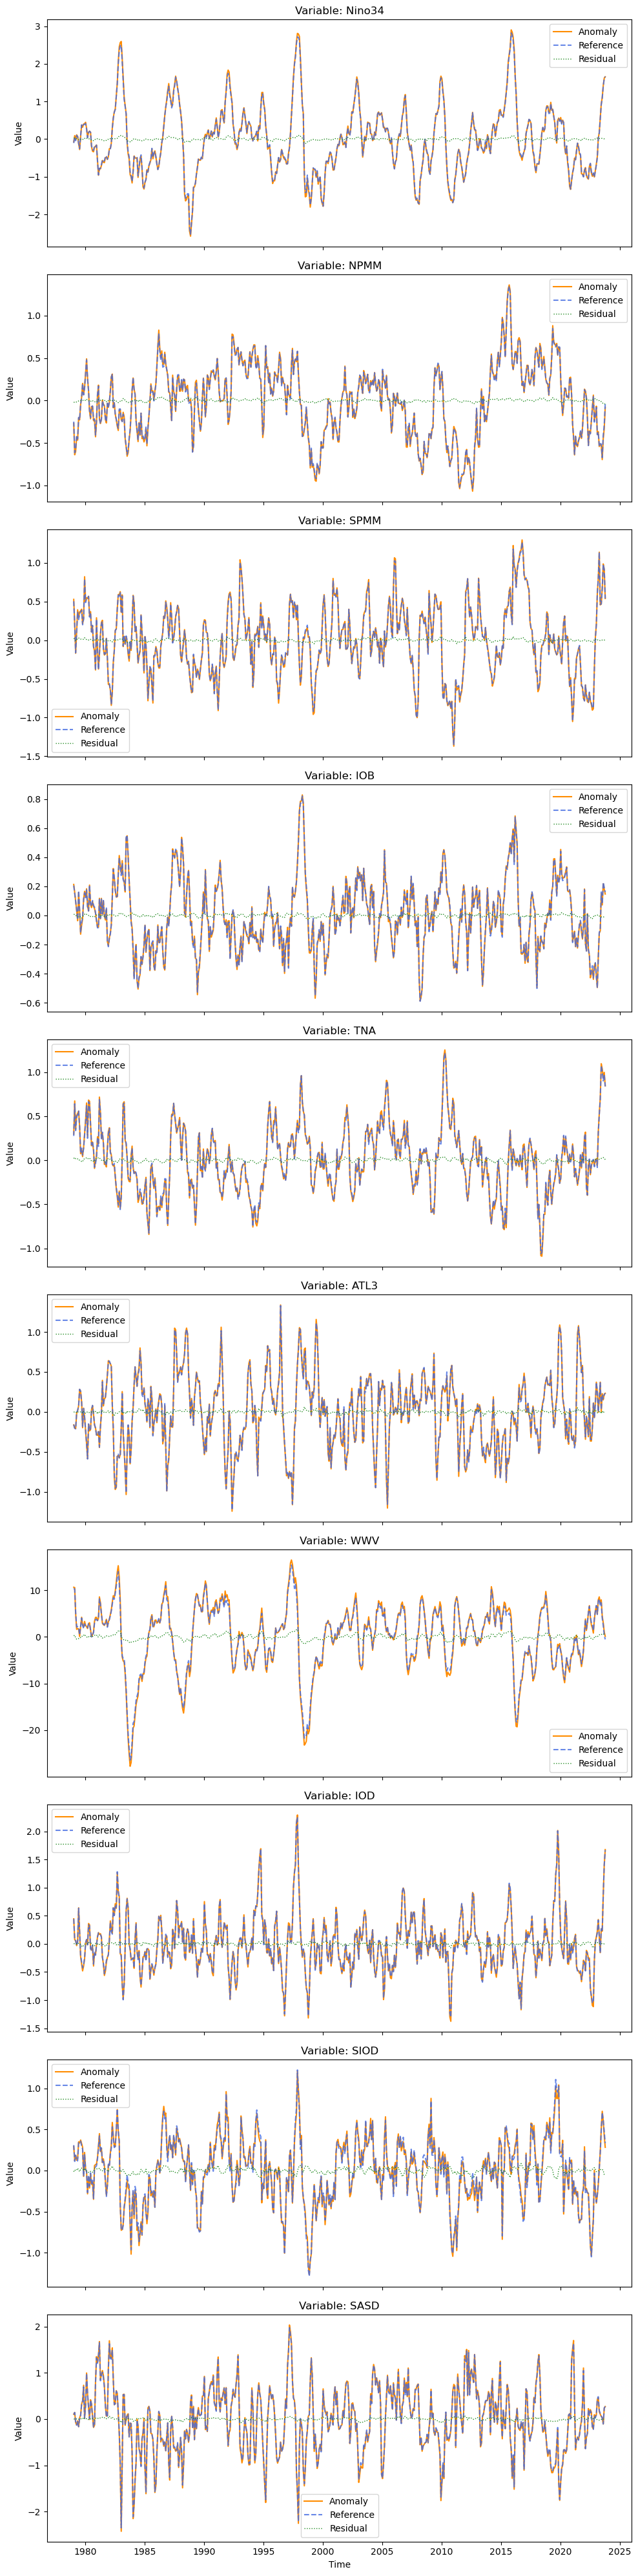

In [4]:
anormaly_ds = cal_anomaly(selected_dataset.sel(time=slice('1979-01-01', '2023-10-31')),
                          dim='time',time_range = slice('1979-01-01', '2023-12-31'),isMv3=False)
oras = xr.open_dataset('indices_oras5.nc').rename({'Hm':'WWV','SASD1':'SASD'})
Validate_with_ref(anormaly_ds,ref_ds=oras,dim='time')

In [ ]:
anormaly_ds = cal_anomaly(selected_dataset,
                          dim='time',time_range = slice('1979-01-01', '2009-12-31'),isMv3=False)
anormaly_ds.to_netcdf('oras5_indices_1958-2025.nc')